In [1]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import gysela_utilities as gys_utils;

# Styling.
plt.style.use("ggplot");

In [2]:
# Test inputs - delete when done!
directory_path = "/zhisongqu_data/seth/GYSELA/raw/batch_10/DN_RHTEST_A3_QUIESCENT";
data_arrays = reader.fetch_conservation_laws_data(directory_path, dataset = "deltaEnkin_tot", parallelise = True);

Found 2001 files in the directory. Loading with 16 workers...


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done 464 tasks      | elapsed:    1.8s


Finished compiling data from all files in the directory.


[Parallel(n_jobs=16)]: Done 2001 out of 2001 | elapsed:    4.1s finished


In [7]:
def plot_conservation_law_time_series(conservation_list, dt_diag, title_suffix = "", log_scale = False):
	
	time_series = np.array([float(entry) for entry in conservation_list]);
	time_range = gys_utils.generate_time_range_by_series(time_series, dt_diag);
	
	dataset_label = r"$\delta E_{KE}$";
	plt.figure(figsize = (10, 5))
	if log_scale:
		plt.semilogy(time_range, np.abs(time_series), color = "firebrick", lw = 2.5, label = dataset_label);
		plt.ylabel(f"|{dataset_label}|", fontsize = 12);
	else:
		plt.plot(time_range, time_series, color = "firebrick", lw = 2.5, label = dataset_label);
		plt.ylabel(dataset_label, fontsize = 12);
	
	plt.title(f"{dataset_label} conservation diagnostic, {title_suffix}", fontsize = 14);
	plt.xlabel("Time [GYSELA code units]", fontsize = 12);
	plt.legend();
	plt.show();

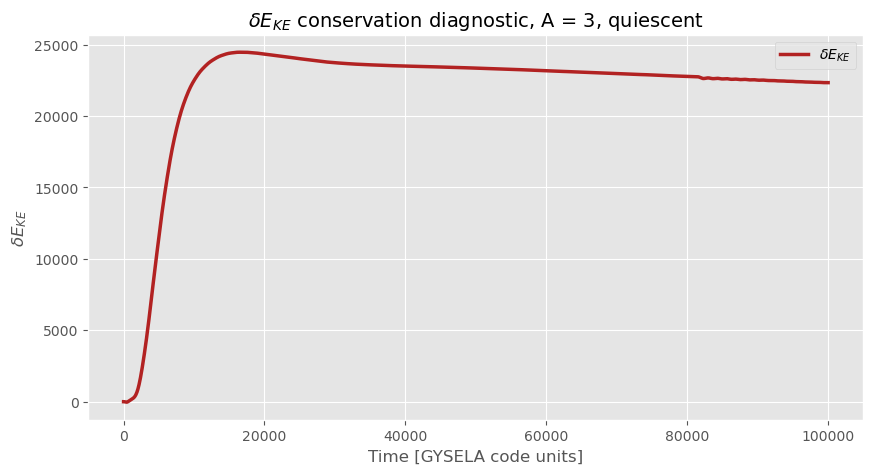

In [8]:
plot_conservation_law_time_series(data_arrays, dt_diag = 50, title_suffix = "A = 3, quiescent");